<a href="https://colab.research.google.com/github/SandraVargasAI/Mineria-de-Datos-/blob/main/MD_S8_Notebook_Ejercitacion_(SV).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background:#0D1B2A;color:white;padding:30px 40px;border-radius:12px;font-family:sans-serif;">
  <p style="color:#0A9396;font-size:13px;letter-spacing:2px;margin:0;">MINERÍA DE DATOS · 2026 · SEMANA 8</p>
  <h1 style="font-size:32px;margin:10px 0 6px 0;color:#FFFFFF;">Notebook de Ejercitación</h1>
  <h2 style="font-size:18px;color:#A8D8EA;font-weight:300;margin:0 0 20px 0;">Aprendizaje Supervisado: Regresión Logística y Regresión Múltiple</h2>
  <div style="background:#E76F51;padding:12px 20px;border-radius:8px;margin:16px 0;">
    <strong>📋 Actividad de Foro — Semana 8:</strong> Completá este notebook y publicá
    tus respuestas de la <strong>Reflexión Final</strong> en el foro del aula.
  </div>
  <hr style="border:1px solid #1C7293;margin:18px 0;">
  <p style="color:#8BADC0;font-size:13px;margin:0;">Nombre: _____SANDRA VARGAS______________ &nbsp;&nbsp; Fecha: _____________</p>
</div>

> **Datasets utilizados:**
> - 🚢 **Titanic** → Regresión Logística (clasificación binaria: ¿sobrevivió?)
> - 🏠 **California Housing** → Regresión Múltiple (predicción de precios)
>
> **Instrucciones:** Completá los bloques `# TODO` y ejecutá cada celda antes de continuar.


---
## ⚙️ Configuración inicial — ejecutar primero


In [ ]:
# ── Imports generales ────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.datasets import fetch_california_housing

sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

# ── Dataset 1: Titanic ───────────────────────────────────────────────
url_titanic = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df_titanic = pd.read_csv(url_titanic)

# ── Dataset 2: California Housing ────────────────────────────────────
housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing["Price"] = housing.target  # en $100,000

print(f"Titanic:          {df_titanic.shape[0]} filas × {df_titanic.shape[1]} columnas")
print(f"California Hsg:   {df_housing.shape[0]} filas × {df_housing.shape[1]} columnas")
print("\n✅ Setup completo. Listo para comenzar.")


Titanic:          891 filas × 12 columnas
California Hsg:   20640 filas × 9 columnas

✅ Setup completo. Listo para comenzar.


---
# 🧠 Bloque 1 — Conceptos previos al modelado

Antes de entrenar cualquier modelo, necesitamos tomar tres decisiones clave:

| Decisión | Pregunta a responder |
|----------|---------------------|
| 1. Tipo de problema | ¿Clasificación o regresión? |
| 2. Features y target | ¿Qué columnas uso? ¿Cuál predigo? |
| 3. Métricas | ¿Cómo sé si el modelo es bueno? |


### 1.1 Exploración inicial de ambos datasets


In [ ]:
# ── Titanic ──────────────────────────────────────────────────────────
print("=== TITANIC ===")
display(df_titanic.head(3))
print("\nNulos:")
print(df_titanic.isnull().sum()[df_titanic.isnull().sum() > 0])


=== TITANIC ===


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S



Nulos:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [ ]:
# ── California Housing ───────────────────────────────────────────────
print("=== CALIFORNIA HOUSING ===")
display(df_housing.head(3))
print("\nNulos:", df_housing.isnull().sum().sum())
print("\nDescripción de Price:")
print(df_housing["Price"].describe().round(3))


=== CALIFORNIA HOUSING ===


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521



Nulos: 0

Descripción de Price:
count    20640.000
mean         2.069
std          1.154
min          0.150
25%          1.196
50%          1.797
75%          2.647
max          5.000
Name: Price, dtype: float64


### 1.2 Ejercicio — Clasificar los problemas


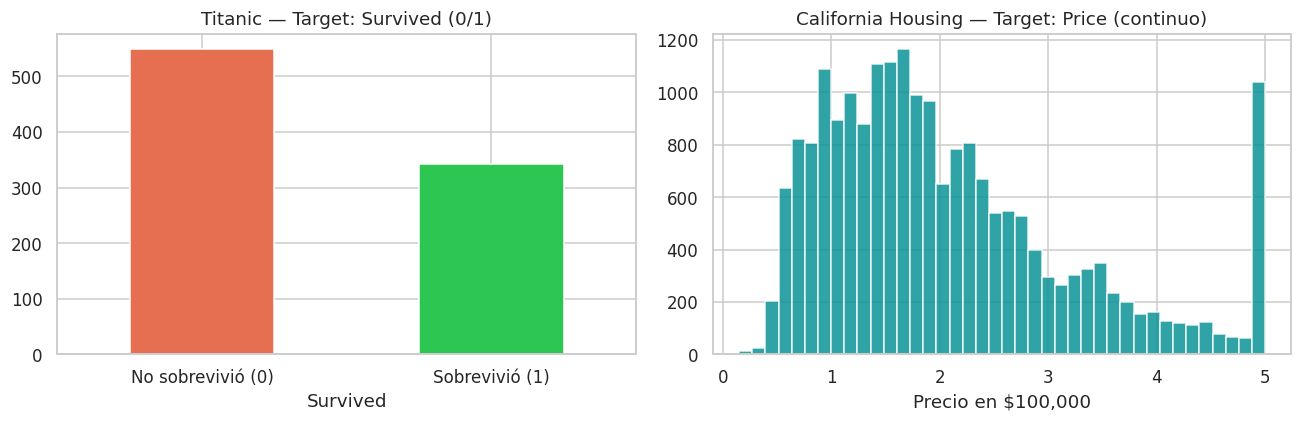

In [ ]:
# TODO: Respondé en los comentarios

# Problema 1 — Titanic
# Variable target: "Survived" (0=no, 1=sí)
# Tipo de problema: ¿clasificación o regresión?
#    R: CLASIFICACION
# Modelo a usar: _______LogisticRegression________
# Métricas apropiadas: _____accuracy_score / precisión / Matriz de Confusion__________

# Problema 2 — California Housing
# Variable target: "Price" (precio en $100,000)
# Tipo de problema: ¿clasificación o regresión?
#    R: REGRESION
# Modelo a usar: ______LinearRegression_________
# Métricas apropiadas: ___R2, MSE, MAE____________

# Ejecutar para ver distribución de los targets
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

df_titanic["Survived"].value_counts().plot(kind="bar", ax=ax1,
    color=["#E76F51", "#2DC653"], edgecolor="white")
ax1.set_title("Titanic — Target: Survived (0/1)")
ax1.set_xticklabels(["No sobrevivió (0)", "Sobrevivió (1)"], rotation=0)

ax2.hist(df_housing["Price"], bins=40, color="#0A9396", edgecolor="white", alpha=0.85)
ax2.set_title("California Housing — Target: Price (continuo)")
ax2.set_xlabel("Precio en $100,000")

plt.tight_layout()
plt.show()


---
# 🧹 Bloque 2 — Preprocesamiento para Modelado

**Regla de oro:** el preprocesamiento se aprende SÓLO en los datos de entrenamiento.
Nunca se hace `fit` en el test set.

```
scaler.fit_transform(X_train)  ✅
scaler.transform(X_test)       ✅
scaler.fit_transform(X_test)   ❌  ← DATA LEAKAGE
```


### 2.1 Preprocesamiento del Titanic


In [ ]:
# ── Features y target para Titanic ──────────────────────────────────
FEATURES_TITANIC = ["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex"]
TARGET_TITANIC   = "Survived"

# Preparar dataset
df_t = df_titanic[FEATURES_TITANIC + [TARGET_TITANIC]].copy()

# Codificar Sex: female=1, male=0 (binaria)
df_t["Sex"] = (df_t["Sex"] == "female").astype(int)

X_t = df_t[FEATURES_TITANIC]
y_t = df_t[TARGET_TITANIC]

print(f"X shape: {X_t.shape}  |  y shape: {y_t.shape}")
print(f"Nulos en X: {X_t.isnull().sum().sum()}")
print("\nDistribución de clases:")
print(y_t.value_counts(normalize=True).round(3))


X shape: (891, 6)  |  y shape: (891,)
Nulos en X: 177

Distribución de clases:
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [ ]:
# ── Train/Test Split con stratify ────────────────────────────────────
X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(
    X_t, y_t,
    test_size=0.2,
    random_state=42,
    stratify=y_t  # mantiene proporción de clases en train y test
)

print(f"Train: {X_t_train.shape[0]} muestras | Test: {X_t_test.shape[0]} muestras")
print(f"Proporción Survived en train: {y_t_train.mean():.3f}")
print(f"Proporción Survived en test:  {y_t_test.mean():.3f}")
print("→ stratify mantiene la proporción similar ✅")


Train: 712 muestras | Test: 179 muestras
Proporción Survived en train: 0.383
Proporción Survived en test:  0.385
→ stratify mantiene la proporción similar ✅


In [ ]:
# ── Imputar nulos en Age + Escalar ───────────────────────────────────
from sklearn.pipeline import Pipeline

# Pipeline: imputa nulos primero, luego escala
preproc_titanic = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

X_t_train_s = preproc_titanic.fit_transform(X_t_train)
X_t_test_s  = preproc_titanic.transform(X_t_test)

print(f"Shape train escalado: {X_t_train_s.shape}")
print(f"Shape test escalado:  {X_t_test_s.shape}")
print("✅ Preprocesamiento Titanic completo")


Shape train escalado: (712, 6)
Shape test escalado:  (179, 6)
✅ Preprocesamiento Titanic completo


### 2.2 Preprocesamiento del California Housing


In [ ]:
# ── Features y target para California Housing ─────────────────────
X_h = df_housing.drop(columns="Price")
y_h = df_housing["Price"]

print(f"Features disponibles: {X_h.columns.tolist()}")
print(f"X shape: {X_h.shape}  |  y shape: {y_h.shape}")
print(f"Nulos: {X_h.isnull().sum().sum()} ✅ Sin nulos")


Features disponibles: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
X shape: (20640, 8)  |  y shape: (20640,)
Nulos: 0 ✅ Sin nulos


In [ ]:
# ── Split y escalar Housing ──────────────────────────────────────────
X_h_train, X_h_test, y_h_train, y_h_test = train_test_split(
    X_h, y_h, test_size=0.2, random_state=42
)

scaler_h = StandardScaler()
X_h_train_s = scaler_h.fit_transform(X_h_train)
X_h_test_s  = scaler_h.transform(X_h_test)

print(f"Train: {X_h_train_s.shape[0]} muestras | Test: {X_h_test_s.shape[0]} muestras")
print("✅ Preprocesamiento California Housing completo")


Train: 16512 muestras | Test: 4128 muestras
✅ Preprocesamiento California Housing completo


### 2.3 Ejercicio — ¿Por qué importa el orden?


In [ ]:
# TODO: Reflexioná sobre las siguientes preguntas

# 1. ¿Por qué usamos stratify=y_t en el Titanic pero NO en Housing?
#    R:en el Titanic, es un problema de Clasificación Binaria (Sobrevivió/No Sobrevivió),
#    por lo tanto se puede dividir de tal forma que queden balanceados los grupos de datos de entrenamiento y el de prueba.
#    En Housing, al ser problema de regresión, no se trata de categorías, por lo cual no es posible dividir equilibraamente.

# 2. ¿Por qué aplicamos fit_transform() al train y sólo transform() al test?
#    ¿Qué información "aprende" el scaler durante el fit?
#    R:durante el fit, el escalador calcula los parámetros estadísticos de los datos. Si usás StandardScaler,
#    aprende la media (μ) y la desviación estándar (σ). Si usás MinMaxScaler, aprende los valores mínimo y máximo.
#    Se aplica solo transform() al conjunto de prueba para usar exactamente los mismos parámetros (media, desviación, etc.) que aprendimos del entrenamiento.
#    Así se garantiza que el modelo sea evaluado en una escala consistente y bajo las mismas condiciones con las que fue entrenado.

# 3. ¿Qué problema ocurriría si escaláramos ANTES de hacer el split?
#    R:Si escalás antes del split, estarías incluyendo información del conjunto de prueba (como su valor máximo o su promedio)
#    dentro de los parámetros de entrenamiento. Sería una evaluación poco realisra.

# ── Demo: comparar con y sin stratify ────────────────────────────────
X_sin_str, _, y_sin_str, _ = train_test_split(X_t, y_t, test_size=0.2, random_state=42)
X_con_str, _, y_con_str, _ = train_test_split(X_t, y_t, test_size=0.2, random_state=42, stratify=y_t)

print(f"Sin stratify — Survived en train: {y_sin_str.mean():.4f}")
print(f"Con stratify — Survived en train: {y_con_str.mean():.4f}")
print(f"Proporción real en dataset:        {y_t.mean():.4f}")


Sin stratify — Survived en train: 0.3764
Con stratify — Survived en train: 0.3834
Proporción real en dataset:        0.3838


---
# 🔴 Bloque 3 — Regresión Logística (Titanic)

La Regresión Logística predice la **probabilidad** de que un ejemplo pertenezca a la clase 1.
Usa la función sigmoide para transformar la combinación lineal de features en un valor entre 0 y 1:

$$\sigma(z) = \frac{1}{1 + e^{-z}} \quad \text{donde} \quad z = \beta_0 + \beta_1 x_1 + ... + \beta_n x_n$$

Con **threshold = 0.5**: si σ(z) ≥ 0.5 → clase 1, si σ(z) < 0.5 → clase 0.


### 3.1 Entrenar el modelo


In [ ]:
# ── Entrenar Regresión Logística ─────────────────────────────────────
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_t_train_s, y_t_train)

# Predicciones
y_t_pred = log_reg.predict(X_t_test_s)
y_t_prob = log_reg.predict_proba(X_t_test_s)[:, 1]  # prob de clase 1

print("Primeras 10 predicciones:")
for i in range(10):
    print(f"  Real: {y_t_test.iloc[i]} | Predicho: {y_t_pred[i]} | P(sobrevivir): {y_t_prob[i]:.3f}")


Primeras 10 predicciones:
  Real: 0 | Predicho: 0 | P(sobrevivir): 0.074
  Real: 0 | Predicho: 0 | P(sobrevivir): 0.052
  Real: 1 | Predicho: 0 | P(sobrevivir): 0.124
  Real: 0 | Predicho: 0 | P(sobrevivir): 0.039
  Real: 1 | Predicho: 1 | P(sobrevivir): 0.563
  Real: 1 | Predicho: 0 | P(sobrevivir): 0.493
  Real: 1 | Predicho: 1 | P(sobrevivir): 0.786
  Real: 0 | Predicho: 0 | P(sobrevivir): 0.344
  Real: 0 | Predicho: 0 | P(sobrevivir): 0.284
  Real: 0 | Predicho: 0 | P(sobrevivir): 0.173


### 3.2 Evaluación completa


In [ ]:
# ── Reporte de clasificación ─────────────────────────────────────────
print("=== REPORTE DE CLASIFICACIÓN ===")
print(classification_report(y_t_test, y_t_pred,
                            target_names=["No sobrevivió", "Sobrevivió"]))

auc = roc_auc_score(y_t_test, y_t_prob)
print(f"AUC-ROC: {auc:.4f}")


=== REPORTE DE CLASIFICACIÓN ===
               precision    recall  f1-score   support

No sobrevivió       0.83      0.87      0.85       110
   Sobrevivió       0.78      0.71      0.74        69

     accuracy                           0.81       179
    macro avg       0.80      0.79      0.80       179
 weighted avg       0.81      0.81      0.81       179

AUC-ROC: 0.8514


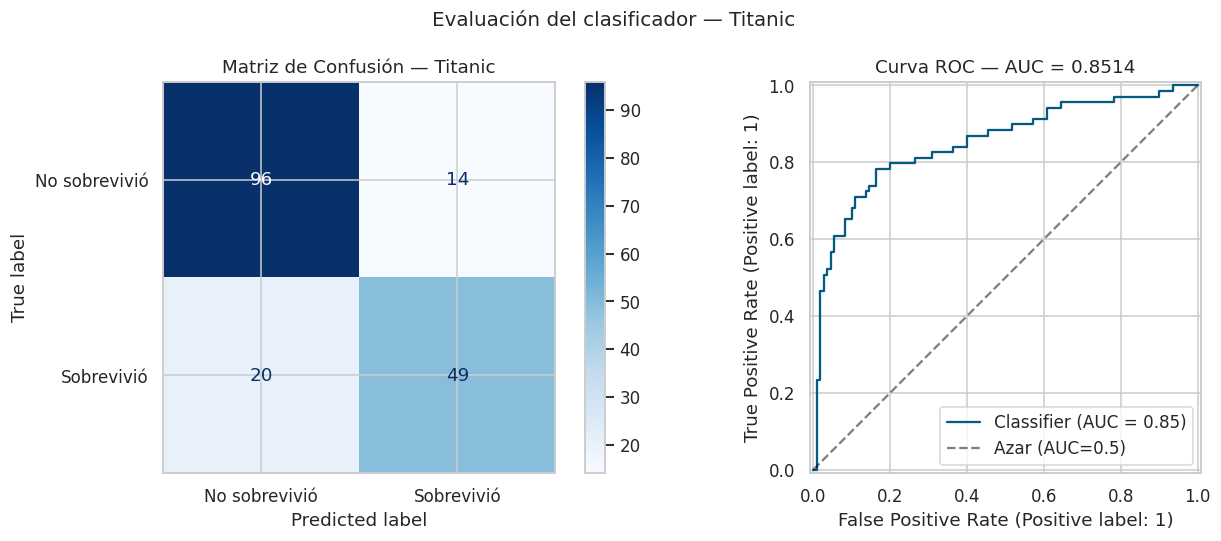

In [ ]:
# ── Visualización: Matriz de Confusión + Curva ROC ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_t_test, y_t_pred,
    display_labels=["No sobrevivió", "Sobrevivió"],
    cmap="Blues", ax=ax1
)
ax1.set_title("Matriz de Confusión — Titanic")

RocCurveDisplay.from_predictions(y_t_test, y_t_prob, ax=ax2, color="#065A82")
ax2.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Azar (AUC=0.5)")
ax2.set_title(f"Curva ROC — AUC = {auc:.4f}")
ax2.legend()

plt.suptitle("Evaluación del clasificador — Titanic", fontsize=13)
plt.tight_layout()
plt.show()


### 3.3 Interpretación de coeficientes


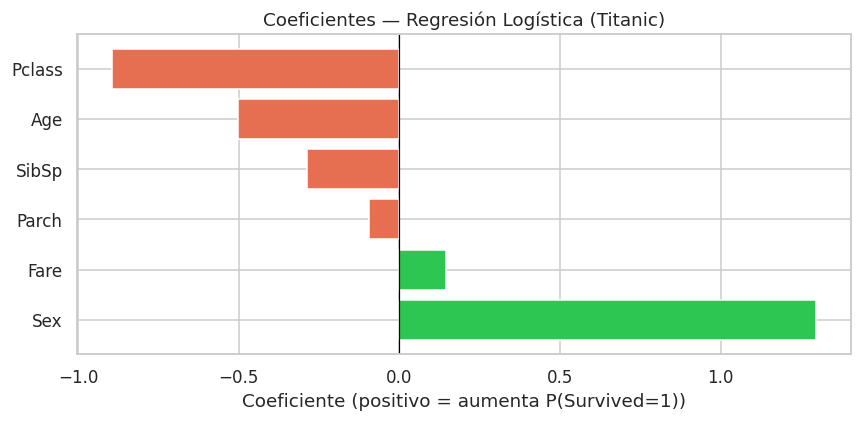

,Feature,Coeficiente
5,Sex,1.297232
4,Fare,0.146167
3,Parch,-0.094613
2,SibSp,-0.287548
1,Age,-0.502813
0,Pclass,-0.893370


In [ ]:
# ── Coeficientes del modelo ───────────────────────────────────────────
coef_df = pd.DataFrame({
    "Feature": FEATURES_TITANIC,
    "Coeficiente": log_reg.coef_[0]
}).sort_values("Coeficiente", ascending=False)

plt.figure(figsize=(8, 4))
colores = ["#2DC653" if c > 0 else "#E76F51" for c in coef_df["Coeficiente"]]
plt.barh(coef_df["Feature"], coef_df["Coeficiente"], color=colores, edgecolor="white")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Coeficientes — Regresión Logística (Titanic)")
plt.xlabel("Coeficiente (positivo = aumenta P(Survived=1))")
plt.tight_layout()
plt.show()

display(coef_df)


### 3.4 Ejercicio — Ajustar el threshold


In [ ]:
# ── Comparar resultados con diferentes thresholds ────────────────────
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

resultados = []
from sklearn.metrics import precision_score, recall_score, f1_score

for t in thresholds:
    y_pred_t = (y_t_prob >= t).astype(int)
    resultados.append({
        "Threshold": t,
        "Accuracy":  (y_pred_t == y_t_test).mean().round(4),
        "Precision": round(precision_score(y_t_test, y_pred_t, zero_division=0), 4),
        "Recall":    round(recall_score(y_t_test, y_pred_t, zero_division=0), 4),
        "F1":        round(f1_score(y_t_test, y_pred_t, zero_division=0), 4),
    })

df_thresh = pd.DataFrame(resultados)
display(df_thresh)

# TODO: Respondé
# 1. ¿Qué le pasa al Recall cuando bajás el threshold a 0.3?
#    R: Cuando el threshold se baja a 0.3, el Recall aumenta (de 0.7101 en 0.5 a 0.7971 en 0.3).
#    Se da prioridad a encontrar la mayor cantidad de sobrevivientes, a riesgo de equivocarse.

# 2. ¿Qué le pasa a la Precision cuando subís el threshold a 0.7?
#    R: Cuando el threshold se sube a 0.7, la Precision aumenta (de 0.7778 en 0.5 a 0.9394 en 0.7).
#    Se pretende predicciones seguras.

# 3. Si quisieras detectar la mayor cantidad posible de sobrevivientes
#    (aunque te equivoques en algunos), ¿qué threshold usarías?
#    R: Para detectar la mayor cantidad posible de sobrevivientes.
#    En esete caso se debe usar un valor bajo.


,Threshold,Accuracy,Precision,Recall,F1
0,0.3,0.7765,0.6790,0.7971,0.7333
1,0.4,0.8045,0.7297,0.7826,0.7552
2,0.5,0.8101,0.7778,0.7101,0.7424
3,0.6,0.8156,0.8750,0.6087,0.7179
4,0.7,0.7765,0.9394,0.4493,0.6078


---
# 🟢 Bloque 4 — Regresión Lineal Múltiple (California Housing)

La Regresión Múltiple predice un **valor numérico continuo** a partir de múltiples variables:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n$$

El modelo encuentra los coeficientes β que **minimizan la suma de errores al cuadrado** (OLS).


### 4.1 Exploración del target — Precio de viviendas


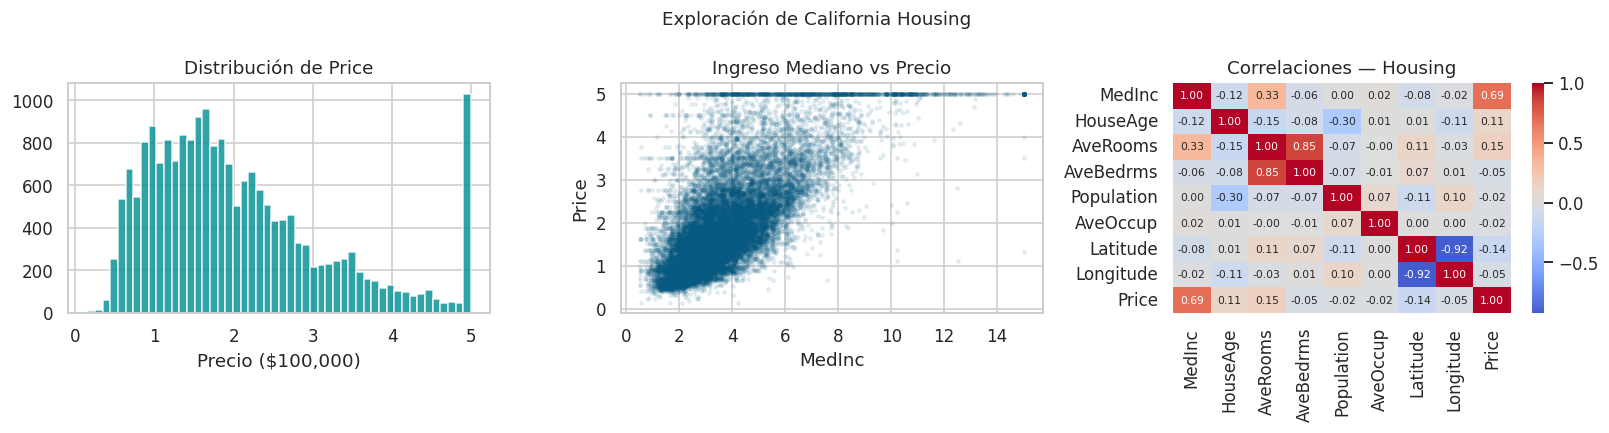

In [ ]:
# ── Distribución y correlaciones del Housing ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución del precio
axes[0].hist(df_housing["Price"], bins=50, color="#0A9396", edgecolor="white", alpha=0.85)
axes[0].set_title("Distribución de Price")
axes[0].set_xlabel("Precio ($100,000)")

# Scatter MedInc vs Price (predictor más correlacionado)
axes[1].scatter(df_housing["MedInc"], df_housing["Price"],
                alpha=0.08, s=5, color="#065A82")
axes[1].set_title("Ingreso Mediano vs Precio")
axes[1].set_xlabel("MedInc")
axes[1].set_ylabel("Price")

# Heatmap de correlaciones
corr = df_housing.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=axes[2], annot_kws={"size":7})
axes[2].set_title("Correlaciones — Housing")

plt.suptitle("Exploración de California Housing", fontsize=12)
plt.tight_layout()
plt.show()


### 4.2 Entrenar LinearRegression y Ridge


In [ ]:
# ── Entrenar ambos modelos ────────────────────────────────────────────
lr_model    = LinearRegression()
ridge_model = Ridge(alpha=1.0)

lr_model.fit(X_h_train_s, y_h_train)
ridge_model.fit(X_h_train_s, y_h_train)

# Predicciones
y_h_pred_lr    = lr_model.predict(X_h_test_s)
y_h_pred_ridge = ridge_model.predict(X_h_test_s)

# ── Métricas ─────────────────────────────────────────────────────────
def metricas_regresion(nombre, y_real, y_pred):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    print(f"{nombre}:")
    print(f"  MAE  = {mae:.4f}  (error promedio en $100,000)")
    print(f"  RMSE = {rmse:.4f}  (error cuadrático medio)")
    print(f"  R²   = {r2:.4f}  (varianza explicada)")
    return {"Modelo": nombre, "MAE": mae, "RMSE": rmse, "R2": r2}

res_lr    = metricas_regresion("LinearRegression", y_h_test, y_h_pred_lr)
print()
res_ridge = metricas_regresion("Ridge(α=1.0)",     y_h_test, y_h_pred_ridge)


LinearRegression:
  MAE  = 0.5332  (error promedio en $100,000)
  RMSE = 0.7456  (error cuadrático medio)
  R²   = 0.5758  (varianza explicada)

Ridge(α=1.0):
  MAE  = 0.5332  (error promedio en $100,000)
  RMSE = 0.7456  (error cuadrático medio)
  R²   = 0.5758  (varianza explicada)


### 4.3 Visualización de predicciones vs valores reales


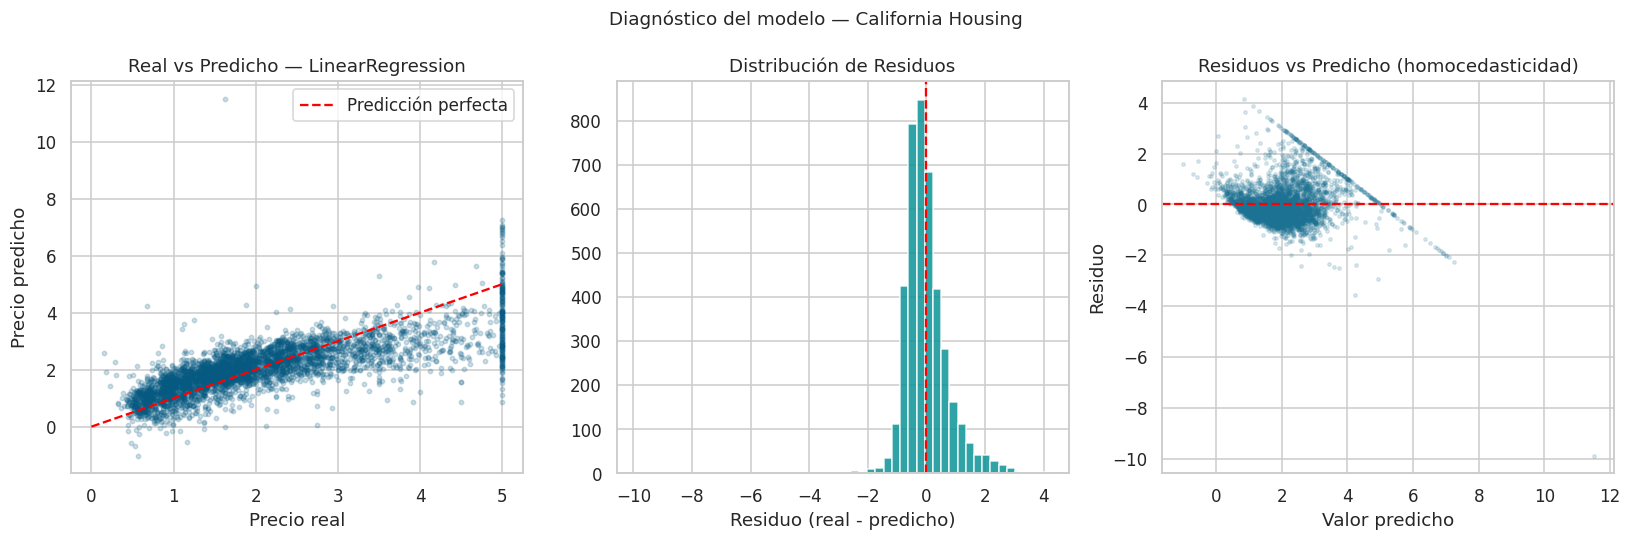

In [ ]:
# ── Predicho vs Real + Distribución de residuos ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter: real vs predicho
axes[0].scatter(y_h_test, y_h_pred_lr, alpha=0.2, s=8, color="#065A82")
axes[0].plot([0, 5], [0, 5], "r--", linewidth=1.5, label="Predicción perfecta")
axes[0].set_xlabel("Precio real")
axes[0].set_ylabel("Precio predicho")
axes[0].set_title("Real vs Predicho — LinearRegression")
axes[0].legend()

# Residuos
residuos = y_h_test - y_h_pred_lr
axes[1].hist(residuos, bins=50, color="#0A9396", edgecolor="white", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Distribución de Residuos")
axes[1].set_xlabel("Residuo (real - predicho)")

# Residuos vs predicho (homoscediasicidad)
axes[2].scatter(y_h_pred_lr, residuos, alpha=0.15, s=5, color="#1C7293")
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Valor predicho")
axes[2].set_ylabel("Residuo")
axes[2].set_title("Residuos vs Predicho (homocedasticidad)")

plt.suptitle("Diagnóstico del modelo — California Housing", fontsize=12)
plt.tight_layout()
plt.show()


### 4.4 Coeficientes — ¿Qué aprendió el modelo?


Coeficientes del modelo (features estandarizadas):


,Feature,LinearReg,Ridge
0,MedInc,0.854383,0.854327
3,AveBedrms,0.339259,0.339008
1,HouseAge,0.122546,0.122624
4,Population,-0.002308,-0.002282
5,AveOccup,-0.040829,-0.040833
2,AveRooms,-0.294410,-0.294210
7,Longitude,-0.869842,-0.869071
6,Latitude,-0.896929,-0.896168


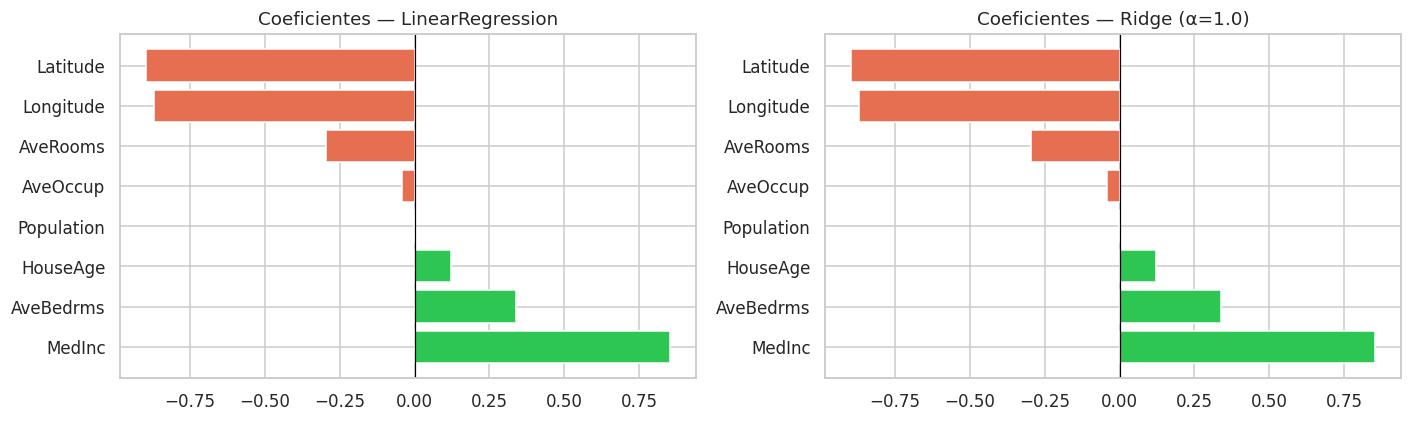

In [ ]:
# ── Visualizar coeficientes (estandarizados → comparables) ──────────
coef_housing = pd.DataFrame({
    "Feature": housing.feature_names,
    "LinearReg": lr_model.coef_,
    "Ridge":     ridge_model.coef_
}).sort_values("LinearReg", ascending=False)

print("Coeficientes del modelo (features estandarizadas):")
display(coef_housing)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, color, titulo in [
    (ax1, "LinearReg", "#065A82", "LinearRegression"),
    (ax2, "Ridge", "#0A9396", "Ridge (α=1.0)")
]:
    colores = ["#2DC653" if v > 0 else "#E76F51" for v in coef_housing[col]]
    ax.barh(coef_housing["Feature"], coef_housing[col], color=colores, edgecolor="white")
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Coeficientes — {titulo}")

plt.tight_layout()
plt.show()


### 4.5 Ejercicio — Mejorar el modelo con Ridge


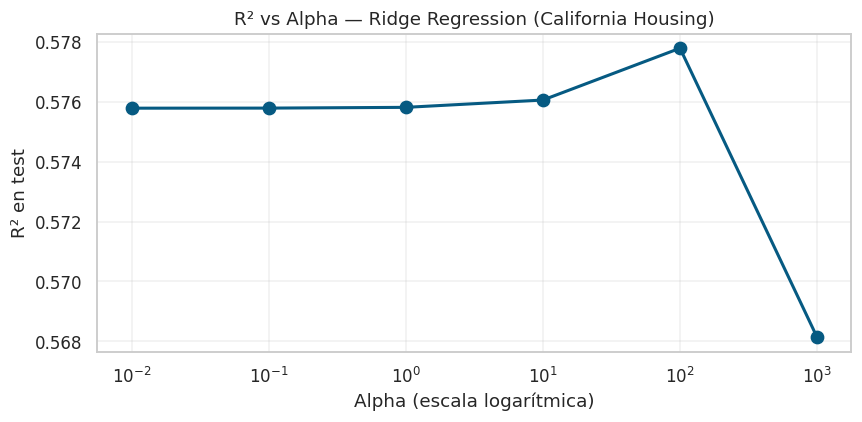

Mejor alpha: 100 → R² = 0.5778


In [ ]:
# TODO: Probá Ridge con diferentes valores de alpha y graficá R² vs alpha
alphas = [0.01, 0.1, 1.0, 10, 100, 1000]
r2_scores = []

for a in alphas:
    ridge_a = Ridge(alpha=a)
    ridge_a.fit(X_h_train_s, y_h_train)
    y_pred_a = ridge_a.predict(X_h_test_s)
    r2_scores.append(r2_score(y_h_test, y_pred_a))

plt.figure(figsize=(8, 4))
plt.semilogx(alphas, r2_scores, "o-", color="#065A82", linewidth=2, markersize=8)
plt.xlabel("Alpha (escala logarítmica)")
plt.ylabel("R² en test")
plt.title("R² vs Alpha — Ridge Regression (California Housing)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mejor_alpha = alphas[np.argmax(r2_scores)]
print(f"Mejor alpha: {mejor_alpha} → R² = {max(r2_scores):.4f}")

# TODO: Respondé
# 1. ¿Qué le pasa al R² cuando alpha es muy grande (ej: 1000)?
#    R: en ese caso R² tiende a bajar.

# 2. ¿Por qué en este caso la diferencia entre LinearRegression y Ridge es pequeña?
#    (Pista: revisá la matriz de correlaciones del Bloque 4.1)
#    R:Ridge corrige la multicolinealidad, se observa en la matriz de correlación
#    que las variables no estan tan correlacionadas. LinearRegression ....


---
# ⚖️ Bloque 5 — Comparación y Análisis Final

En este bloque comparamos ambos modelos y tomamos decisiones de ingeniería.


### 5.1 Tabla comparativa de resultados


In [ ]:
# ── Tabla comparativa ────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

tabla = {
    "Modelo":       ["LogisticRegression (Titanic)", "LinearRegression (Housing)", "Ridge α=1 (Housing)"],
    "Problema":     ["Clasificación binaria",        "Regresión continua",         "Regresión continua"],
    "Métrica 1":    [
        f"Accuracy={accuracy_score(y_t_test, y_t_pred):.3f}",
        f"MAE={mean_absolute_error(y_h_test, y_h_pred_lr):.3f}",
        f"MAE={mean_absolute_error(y_h_test, y_h_pred_ridge):.3f}"
    ],
    "Métrica 2":    [
        f"AUC={roc_auc_score(y_t_test, y_t_prob):.3f}",
        f"R²={r2_score(y_h_test, y_h_pred_lr):.3f}",
        f"R²={r2_score(y_h_test, y_h_pred_ridge):.3f}"
    ],
}

display(pd.DataFrame(tabla))


,Modelo,Problema,Métrica 1,Métrica 2
0,LogisticRegression (Titanic),Clasificación binaria,Accuracy=0.810,AUC=0.851
1,LinearRegression (Housing),Regresión continua,MAE=0.533,R²=0.576
2,Ridge α=1 (Housing),Regresión continua,MAE=0.533,R²=0.576


### 5.2 Ejercicio integrador — Decisión de modelo


In [ ]:
# TODO: Para cada escenario, indicá qué modelo usarías y por qué

# Escenario A: Un banco quiere predecir si un cliente va a incumplir un préstamo (sí/no)
# Modelo: __Regrasión Logística___  Métricas principales: __recall, matriz de confusión_____________
# ¿Por qué esas métricas? (Pista: piensa en el costo de un falso negativo)
#    R: predice una variable categórica binaria. Un nfalso negativo, implica que se predice que el cliente paga, pero en realidad no es así.
#    Es un error muy costoso, implica pérdida del capital prestado. Priorizar Recall.

# Escenario B: Una inmobiliaria quiere estimar el precio de venta de un departamento
# Modelo: ___Reegresión Múltiple______  Métricas principales: __R2, MSE, MAE_____________
#    R:predice una variable numérica continuua.

# Escenario C: Una app de salud quiere detectar si un paciente tiene diabetes (sí/no)
# Modelo: ___Regresión Logística____  ¿Qué métrica priorizarías: Precision o Recall? ¿Por qué?
#    R: prioriza Recall, en temas médicos no se debe aceptar unfalso negativo.

# Escenario D: Un restaurant quiere predecir cuántos cubiertos servirá el próximo viernes
# Modelo: ____Regresión Míltiple___  Métricas principales: ____MAE, MSE______
#    R: predice un valor numérico. Ambas métricas miden el error entre la predicción y lo real.


### 5.3 Experimento — Quitar y agregar features


In [ ]:
# ── ¿Qué pasa si usamos menos features en Logística? ─────────────────
resultados_features = []

subsets = {
    "Sólo Pclass":           ["Pclass"],
    "Pclass + Sex":          ["Pclass", "Sex"],
    "Top 3 (+ Age)":         ["Pclass", "Sex", "Age"],
    "Top 4 (+ Fare)":        ["Pclass", "Sex", "Age", "Fare"],
    "Todos (6 features)":    FEATURES_TITANIC,
}

for nombre, feats in subsets.items():
    Xf = df_t[feats]
    Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(Xf, y_t, test_size=0.2, random_state=42, stratify=y_t)
    pip = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
    Xf_tr_s = pip.fit_transform(Xf_tr)
    Xf_te_s = pip.transform(Xf_te)
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(Xf_tr_s, yf_tr)
    y_pr = m.predict(Xf_te_s)
    y_pb = m.predict_proba(Xf_te_s)[:, 1]
    resultados_features.append({
        "Subset": nombre,
        "N_features": len(feats),
        "Accuracy": round(accuracy_score(yf_te, y_pr), 4),
        "AUC": round(roc_auc_score(yf_te, y_pb), 4),
        "F1": round(f1_score(yf_te, y_pr), 4)
    })

df_feats = pd.DataFrame(resultados_features)
display(df_feats)

# TODO: ¿Cuál combinación de features lográs el mejor equilibrio AUC/interpretabilidad?
#    R: La combinación que suele lograr el mejor equilibrio entre AUC e interpretabilidad es “Top 3 (+ Age)” o “Top 4 (+ Fare)”,
#    porque incorpora variables relevantes sin volver el modelo demasiado complejo.
#    Agregar todas las variables puede aumentar apenas el rendimiento, pero también hace el modelo más difícil de analizar y puede introducir ruido o redundancia.

,Subset,N_features,Accuracy,AUC,F1
0,Sólo Pclass,1,0.6425,0.6682,0.4386
1,Pclass + Sex,2,0.7765,0.8217,0.6923
2,Top 3 (+ Age),3,0.7933,0.8368,0.7218
3,Top 4 (+ Fare),4,0.7933,0.8381,0.7218
4,Todos (6 features),6,0.8101,0.8514,0.7424


---
## 💬 Reflexión Final — Para publicar en el Foro

<div style="background:#E76F51;color:white;padding:14px 20px;border-radius:8px;">
  <strong>📋 Instrucción:</strong> Respondé las siguientes preguntas en la celda de código.
  Luego copiá tus respuestas y publicalas en el foro del aula para completar la actividad de la semana.
</div>


In [ ]:
# ═══ REFLEXIÓN FINAL — COMPLETAR Y PUBLICAR EN EL FORO ═══════════════

# 1. ¿Qué es lo que diferencia a la Regresión Logística de la Regresión Múltiple?
#    No lo respondas sólo en términos de fórmula — explicalo con un ejemplo propio.
#    R:La Regresión Múltiple y la Regresión Logística se diferencian en el tipo de resultado que predicen.
#    La primera estima un valor numérico, mientras que la segunda clasifica en categorías a partir de probabilidades.
#    Ejemplo, una inmobiliaria puede usar Regresión Múltiple para predecir que una casa costará “$250.000”,
#    mientras que la Regresión Logística puede indicar 85% de probabilidad de que la casa se venda este mes.

# 2. En el experimento de subsets de features (Bloque 5.3), ¿observaste que agregar
#    más features siempre mejora el modelo? ¿Qué conclusión podés sacar?
#    R:Según lo observado, agregar mas features no siempre produce mejora en el modelo.
#    Si lo agregado no tiene corrrelación con la variable principal, agregamos ruido.
#    Conclusión: definir bien las variables que utilizaremos, nos beneficia en calidad del modelo
#    y nos evita previene de riesgod asociado al exceso de varaibles irrelevantes.

# 3. En el Bloque 3.4 viste el trade-off Precision/Recall al cambiar el threshold.
#    Inventá un escenario real donde priorizarías el Recall sobre la Precision.
#    ¿Por qué el costo de los falsos negativos es mayor en ese caso?
#    R: Caso de detección de falla crítica en un tren, se busca identificar si el eje del tren sufrirá rotura.
#    En este caso el Recall representa la capacidad el modelo para identificar todas las fallas reales antes de que ocurran.
#    Un Falso Negativo, diagnostico de eje sano cuando en realidad presenta problemas, puede causaar descarrilamiento del tren.

# 4. R² del modelo de housing fue ~0.60.
#    ¿Qué información/features adicionales crees que mejorarían las predicciones?
#    ¿Qué limitaciones tiene la regresión lineal para este tipo de problema?
#    R:Podemos agregar variables que definan como seguridad, cercanía a colegios,
#    acceso a transporte o mas detalles propios de la vivienda.
#    Una de las limitaciones fundamentales de la Regresión Lineal es que asume una relación lineal constante y proporcional
#    entre las variables predictoras y la variable objetivo.
#    Por ejemplo, dos casas con la misma superficie pueden tener precios muy distintos si una está cerca del centro
#    y otra en una zona alejada. La Regresión lineal no representa bien relaciones no lineales complejas del mercado inmobiliario.

---
<div style="background:#0D1B2A;color:#8BADC0;padding:20px 30px;border-radius:10px;font-family:sans-serif;">
  <p style="color:#0A9396;font-size:12px;letter-spacing:2px;margin:0 0 8px 0;">MINERÍA DE DATOS · 2026 · SEMANA 8</p>
  <p style="font-size:15px;color:#FFFFFF;margin:0 0 6px 0;"><strong>Notebook completado ✓</strong></p>
  <p style="font-size:13px;margin:0 0 10px 0;">Logística (Titanic) · Múltiple (California Housing) · Métricas · Threshold · Ridge</p>
  <hr style="border:1px solid #1C7293;margin:14px 0;">
  <p style="font-size:12px;margin:0;color:#F4A261;">📌 Próxima semana: Árboles de Decisión — un modelo que no necesita escalar y es completamente interpretable.</p>
</div>
